# Partial Correlation — Full Galaxy Population (All Morphological Types)

Replicates `PartialCorrelation_HaloMassControl.ipynb` but without restricting to ellipticals.

This gives a much larger sample and tests whether the halo-mass mediation result holds
across the full galaxy population, not just the pre-selected red sequence.

**Key difference from elliptical-only analysis:**
- No VisualMorphology join or ELLIPTICAL_CODE filter
- Full dynamic range in u−r colour (blue through red)
- Larger N → more statistical power


In [1]:
from astropy.table import Table, join
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## 1. Load and Join Data (all galaxy types)

In [2]:
# Group catalogue
ForGroup = Table.read('../../GAMA_DATA/G3CFoFGroupv10.fits')
print(f'ForGroup: {len(ForGroup)}')

# Galaxy group membership — all galaxies in groups
GroupGal = Table.read('../../GAMA_DATA/G3CGalv10.fits')
GroupGal = GroupGal[GroupGal['GroupID'] > 0]
print(f'GroupGal (in groups): {len(GroupGal)}')

# Stellar masses / colours — all types
StellarMasses = Table.read('../../GAMA_DATA/StellarMassesLambdarv24.fits')
StellarMasses = StellarMasses[StellarMasses['uminusr'] > 0.01]
StellarMasses = StellarMasses[StellarMasses['uminusr'] < 5]
StellarMasses = StellarMasses[StellarMasses['logmstar'] > 0.01]
StellarMasses = StellarMasses['CATAID', 'uminusr', 'logmstar']
print(f'StellarMasses: {len(StellarMasses)}')

# Environment measures
envMeasures = Table.read('../../GAMA_DATA/EnvironmentMeasuresv06.fits')
envMeasures = envMeasures[envMeasures['SurfaceDensity'] > 0]
envMeasures = envMeasures[envMeasures['SurfaceDensity'] < 50]
envMeasures = envMeasures[envMeasures['AGEDenParFlag'] == 0]
envMeasures = envMeasures[envMeasures['CountInCylFlag'] == 0]
envMeasures = envMeasures[envMeasures['CountInCyl'] > 0]
envMeasures = envMeasures[envMeasures['SurfaceDensityFlag'] == 0]
print(f'envMeasures (clean): {len(envMeasures)}')

ForGroup: 26194
GroupGal (in groups): 83093


StellarMasses: 199326
envMeasures (clean): 50827


In [3]:
# Join — no morphology filter
galData = join(GroupGal['CATAID', 'GroupID'], StellarMasses, keys='CATAID', join_type='inner')
galData = join(galData, 
               envMeasures[['CATAID','CountInCyl','DistanceTo5nn','SurfaceDensity','AGEDenPar']], 
               keys='CATAID', join_type='inner')
print(f'Joined (all types, in groups): {len(galData)}')

# Attach group halo mass
groupInfo = ForGroup['GroupID', 'MassA', 'TotRmag']
galData = join(galData, groupInfo, keys='GroupID', join_type='inner')
galData = galData[galData['MassA'] > 0]
print(f'After MassA filter: {len(galData)}')

Joined (all types, in groups): 23668


After MassA filter: 22531


## 2. Helper Functions

In [4]:
def residualise(y, x):
    slope, intercept, _, _, _ = stats.linregress(x, y)
    return y - (slope * x + intercept)

def partial_corr(y, x, covariate):
    res_y = residualise(y, covariate)
    res_x = residualise(x, covariate)
    pr, pp = stats.pearsonr(res_y, res_x)
    sr, sp = stats.spearmanr(res_y, res_x)
    return pr, pp, sr, sp

def raw_corr(y, x):
    pr, pp = stats.pearsonr(y, x)
    sr, sp = stats.spearmanr(y, x)
    return pr, pp, sr, sp

print('Helpers defined')

Helpers defined


## 3. Individual Galaxy Level — All Types

In [5]:
log_mass = np.log10(np.array(galData['MassA'], dtype=float))
uminusr  = np.array(galData['uminusr'], dtype=float)
env_fields = ['CountInCyl', 'DistanceTo5nn', 'SurfaceDensity', 'AGEDenPar']

print('=== INDIVIDUAL GALAXY LEVEL (all types) ===')
print(f'N = {len(uminusr)}')
print()
print(f'{"Environment":<20} {"Raw Pearson":>12} {"Raw p":>12} {"Partial Pearson":>16} {"Partial p":>12} {"Change":>8}')
print('-' * 85)

results_individual = []
for field in env_fields:
    env = np.log10(np.array(galData[field], dtype=float))
    raw_pr, raw_pp, raw_sr, raw_sp = raw_corr(uminusr, env)
    par_pr, par_pp, par_sr, par_sp = partial_corr(uminusr, env, log_mass)
    change = par_pr - raw_pr
    print(f'log({field:<16}) {raw_pr:>12.4f} {raw_pp:>12.3e} {par_pr:>16.4f} {par_pp:>12.3e} {change:>+8.4f}')
    results_individual.append({
        'env': f'log({field})',
        'raw_pearson': raw_pr, 'raw_p': raw_pp,
        'raw_spearman': raw_sr,
        'partial_pearson': par_pr, 'partial_p': par_pp,
        'partial_spearman': par_sr,
    })

=== INDIVIDUAL GALAXY LEVEL (all types) ===
N = 22531

Environment           Raw Pearson        Raw p  Partial Pearson    Partial p   Change
-------------------------------------------------------------------------------------
log(CountInCyl      )       0.2397   8.265e-292           0.1094    6.797e-61  -0.1303
log(DistanceTo5nn   )      -0.2446   2.665e-304          -0.1242    3.945e-78  +0.1205
log(SurfaceDensity  )       0.2448   1.125e-304           0.1243    3.007e-78  -0.1205
log(AGEDenPar       )       0.1783   2.361e-160           0.1042    1.939e-55  -0.0741


## 4. Group Level — All Types

In [6]:
df = galData.to_pandas()
df['log_CountInCyl']    = np.log10(df['CountInCyl'])
df['log_DistanceTo5nn'] = np.log10(df['DistanceTo5nn'])
df['log_SurfaceDensity']= np.log10(df['SurfaceDensity'])
df['log_AGEDenPar']     = np.log10(df['AGEDenPar'])
df['log_MassA']         = np.log10(df['MassA'])

group_df = df.groupby('GroupID').agg(
    mean_uminusr        = ('uminusr', 'mean'),
    red_fraction        = ('uminusr', lambda x: (x > 2.1).mean()),  # red = u-r > 2.1
    mean_log_CountInCyl = ('log_CountInCyl', 'mean'),
    mean_log_Dist5nn    = ('log_DistanceTo5nn', 'mean'),
    mean_log_SurfDen    = ('log_SurfaceDensity', 'mean'),
    mean_log_AGEDenPar  = ('log_AGEDenPar', 'mean'),
    log_MassA           = ('log_MassA', 'first'),
    TotRmag             = ('TotRmag', 'first'),
    n_members           = ('CATAID', 'count')
).reset_index()

group_df = group_df[group_df['n_members'] >= 2]
print(f'Groups (>=2 members, all types): {len(group_df)}')

log_mass_g = group_df['log_MassA'].values
mean_ur    = group_df['mean_uminusr'].values
red_frac   = group_df['red_fraction'].values

env_group_fields = {
    'log(CountInCyl)':    group_df['mean_log_CountInCyl'].values,
    'log(DistanceTo5nn)': group_df['mean_log_Dist5nn'].values,
    'log(SurfaceDensity)':group_df['mean_log_SurfDen'].values,
    'log(AGEDenPar)':     group_df['mean_log_AGEDenPar'].values,
}

for ylabel, ydata in [('mean u-r', mean_ur), ('red fraction', red_frac)]:
    print(f'\n=== GROUP LEVEL — {ylabel} ===')
    print(f'{"Environment":<22} {"Raw Pearson":>12} {"Raw p":>12} {"Partial Pearson":>16} {"Partial p":>12} {"Change":>8}')
    print('-' * 87)
    for label, env in env_group_fields.items():
        raw_pr, raw_pp, _, _ = raw_corr(ydata, env)
        par_pr, par_pp, _, _ = partial_corr(ydata, env, log_mass_g)
        change = par_pr - raw_pr
        print(f'{label:<22} {raw_pr:>12.4f} {raw_pp:>12.3e} {par_pr:>16.4f} {par_pp:>12.3e} {change:>+8.4f}')

Groups (>=2 members, all types): 5775

=== GROUP LEVEL — mean u-r ===
Environment             Raw Pearson        Raw p  Partial Pearson    Partial p   Change
---------------------------------------------------------------------------------------
log(CountInCyl)              0.2341    0.000e+00           0.1603    1.478e-34  -0.0738
log(DistanceTo5nn)          -0.2277    0.000e+00          -0.1532    1.109e-31  +0.0745
log(SurfaceDensity)          0.2280    0.000e+00           0.1534    9.154e-32  -0.0745
log(AGEDenPar)               0.1541    5.027e-32           0.1276    2.205e-22  -0.0265

=== GROUP LEVEL — red fraction ===
Environment             Raw Pearson        Raw p  Partial Pearson    Partial p   Change
---------------------------------------------------------------------------------------
log(CountInCyl)              0.2081    0.000e+00           0.1414    3.666e-27  -0.0668
log(DistanceTo5nn)          -0.2074    0.000e+00          -0.1406    6.961e-27  +0.0668


log(SurfaceDensity)          0.2076    0.000e+00           0.1408    5.683e-27  -0.0668


log(AGEDenPar)               0.1103    4.253e-17           0.0851    9.138e-11  -0.0252


## 5. Visualisation

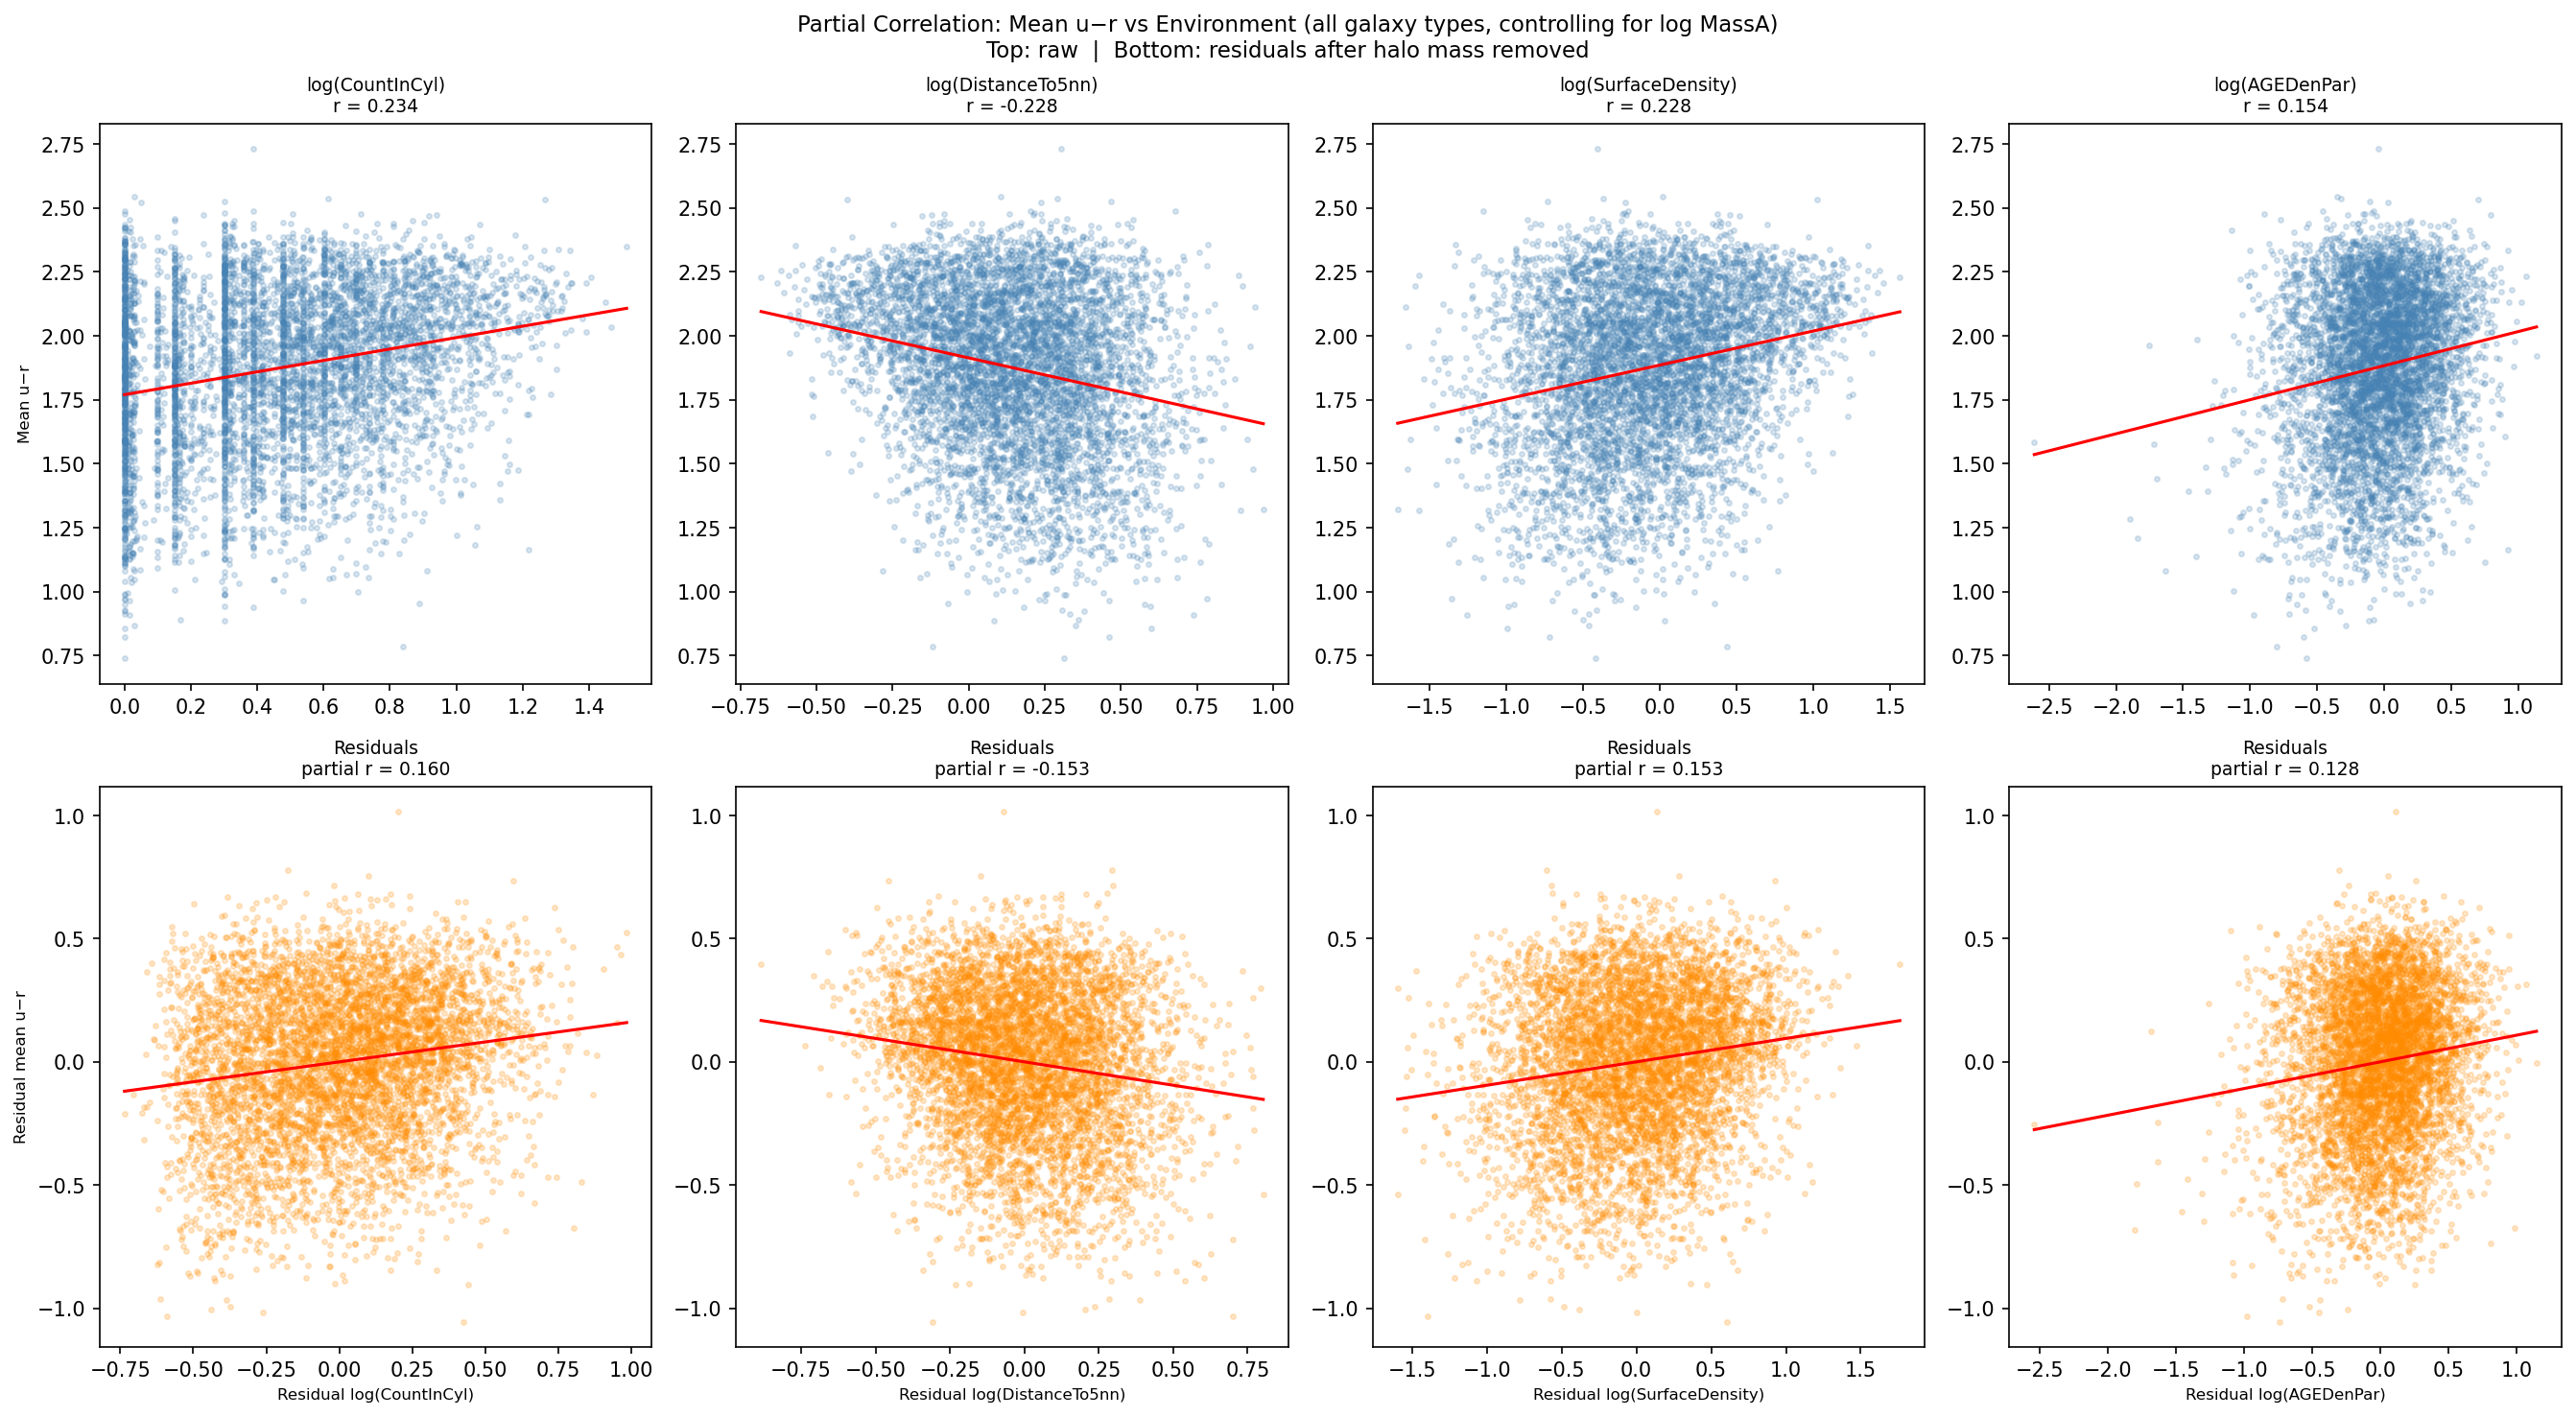

Saved to ChartsPlots/


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10), dpi=150)
fig.suptitle('Partial Correlation: Mean u−r vs Environment (all galaxy types, controlling for log MassA)\n'
             'Top: raw  |  Bottom: residuals after halo mass removed', fontsize=11)

res_ur = residualise(mean_ur, log_mass_g)

for col, (label, env) in enumerate(env_group_fields.items()):
    res_env = residualise(env, log_mass_g)
    raw_r, _, _, _ = raw_corr(mean_ur, env)
    par_r, _, _, _ = partial_corr(mean_ur, env, log_mass_g)

    ax = axes[0, col]
    ax.scatter(env, mean_ur, alpha=0.2, s=6, color='steelblue')
    m, c, _, _, _ = stats.linregress(env, mean_ur)
    xr = np.linspace(env.min(), env.max(), 100)
    ax.plot(xr, m*xr+c, 'r-', lw=1.5)
    ax.set_title(f'{label}\nr = {raw_r:.3f}', fontsize=9)
    if col == 0: ax.set_ylabel('Mean u−r', fontsize=8)

    ax2 = axes[1, col]
    ax2.scatter(res_env, res_ur, alpha=0.2, s=6, color='darkorange')
    m2, c2, _, _, _ = stats.linregress(res_env, res_ur)
    xr2 = np.linspace(res_env.min(), res_env.max(), 100)
    ax2.plot(xr2, m2*xr2+c2, 'r-', lw=1.5)
    ax2.set_title(f'Residuals\npartial r = {par_r:.3f}', fontsize=9)
    ax2.set_xlabel(f'Residual {label}', fontsize=8)
    if col == 0: ax2.set_ylabel('Residual mean u−r', fontsize=8)

plt.tight_layout()
plt.savefig('../../ChartsPlots/PartialCorrelation_HaloMass_AllGalaxies.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to ChartsPlots/')

## 6. Summary

In [8]:
print('=' * 90)
print('SUMMARY — Full galaxy population')
print('=' * 90)

print('\n--- INDIVIDUAL GALAXY LEVEL ---')
print(f'{"Environment":<22} {"Raw r":>8} {"Partial r":>10} {"% change":>10} {"Sig after control?":>20}')
print('-' * 75)
for r in results_individual:
    pct = 100 * (r['partial_pearson'] - r['raw_pearson']) / abs(r['raw_pearson']) if r['raw_pearson'] != 0 else 0
    sig = 'Yes (p<0.05)' if r['partial_p'] < 0.05 else 'No'
    print(f"{r['env']:<22} {r['raw_pearson']:>8.4f} {r['partial_pearson']:>10.4f} {pct:>+9.1f}% {sig:>20}")

print()
print('Interpretation:')
print('  Compare these results with the elliptical-only analysis.')
print('  If partial r collapses to ~0: halo mass fully mediates environment effect.')
print('  If partial r remains significant: independent environment signal exists.')

SUMMARY — Full galaxy population

--- INDIVIDUAL GALAXY LEVEL ---
Environment               Raw r  Partial r   % change   Sig after control?
---------------------------------------------------------------------------
log(CountInCyl)          0.2397     0.1094     -54.4%         Yes (p<0.05)
log(DistanceTo5nn)      -0.2446    -0.1242     +49.2%         Yes (p<0.05)
log(SurfaceDensity)      0.2448     0.1243     -49.2%         Yes (p<0.05)
log(AGEDenPar)           0.1783     0.1042     -41.6%         Yes (p<0.05)

Interpretation:
  Compare these results with the elliptical-only analysis.
  If partial r collapses to ~0: halo mass fully mediates environment effect.
  If partial r remains significant: independent environment signal exists.
